# Alberta Post-Secondary Enrolment Analytics

## 02 — Exploratory Data Analysis

### Objective

Analyze historical post-secondary enrolment patterns across Alberta
institutions from 2014/15 through 2023/24.

### Research Questions

1. How has total Alberta post-secondary enrolment changed over the study period?
2. How has University of Alberta enrolment changed?
3. How does University of Alberta growth compare with Alberta overall?
4. What year-over-year changes are visible in the data?
5. What share of Alberta post-secondary enrolment is represented by the University of Alberta?
6. Which institutions experienced the strongest growth or decline?
7. Are there periods of unusual enrolment change that warrant further investigation?

### Important Analytical Limitation

This analysis describes historical associations and trends. Changes in
enrolment should not be attributed to specific economic, demographic,
policy, or technological factors without additional evidence.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)

In [3]:
file_path = "../data/processed/alberta_enrolment_2014_2024_clean.csv"

df = pd.read_csv(file_path)

df.head()

,Province,Institution,Record_Type,Academic_Year,Academic_Year_Start,Academic_Year_End,Enrolment
0,Alberta,Alberta,Province Total,2014/2015,2014,2015,184026
1,Alberta,Alberta,Province Total,2015/2016,2015,2016,185679
2,Alberta,Alberta,Province Total,2016/2017,2016,2017,190947
3,Alberta,Alberta,Province Total,2017/2018,2017,2018,194010
4,Alberta,Alberta,Province Total,2018/2019,2018,2019,200391


In [4]:
df.shape

(260, 7)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 260 entries, 0 to 259
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Province             260 non-null    str  
 1   Institution          260 non-null    str  
 2   Record_Type          260 non-null    str  
 3   Academic_Year        260 non-null    str  
 4   Academic_Year_Start  260 non-null    int64
 5   Academic_Year_End    260 non-null    int64
 6   Enrolment            260 non-null    int64
dtypes: int64(3), str(4)
memory usage: 26.6 KB


In [6]:
alberta = (
    df[df["Record_Type"] == "Province Total"]
    .sort_values("Academic_Year_Start")
    .copy()
)

alberta[
    ["Academic_Year", "Enrolment"]
]

,Academic_Year,Enrolment
0,2014/2015,184026
1,2015/2016,185679
2,2016/2017,190947
3,2017/2018,194010
4,2018/2019,200391
5,2019/2020,203823
6,2020/2021,203523
7,2021/2022,203580
8,2022/2023,205734
9,2023/2024,216957


In [7]:
alberta_start = alberta.iloc[0]["Enrolment"]
alberta_end = alberta.iloc[-1]["Enrolment"]

alberta_growth = (
    (alberta_end - alberta_start)
    / alberta_start
) * 100

print(f"Starting enrolment: {alberta_start:,.0f}")
print(f"Ending enrolment: {alberta_end:,.0f}")
print(f"10-year change: {alberta_end - alberta_start:,.0f}")
print(f"10-year growth: {alberta_growth:.2f}%")

Starting enrolment: 184,026
Ending enrolment: 216,957
10-year change: 32,931
10-year growth: 17.89%


In [8]:
number_of_periods = (
    alberta["Academic_Year_Start"].max()
    - alberta["Academic_Year_Start"].min()
)

alberta_cagr = (
    (alberta_end / alberta_start)
    ** (1 / number_of_periods)
    - 1
) * 100

print(f"Alberta enrolment CAGR: {alberta_cagr:.2f}%")

Alberta enrolment CAGR: 1.85%


In [9]:
alberta["YoY_Change"] = (
    alberta["Enrolment"].diff()
)

alberta["YoY_Growth_Pct"] = (
    alberta["Enrolment"].pct_change() * 100
)

alberta[
    [
        "Academic_Year",
        "Enrolment",
        "YoY_Change",
        "YoY_Growth_Pct"
    ]
]

,Academic_Year,Enrolment,YoY_Change,YoY_Growth_Pct
0,2014/2015,184026,NaN,NaN
1,2015/2016,185679,"1,653.00",0.90
2,2016/2017,190947,"5,268.00",2.84
3,2017/2018,194010,"3,063.00",1.60
4,2018/2019,200391,"6,381.00",3.29
5,2019/2020,203823,"3,432.00",1.71
6,2020/2021,203523,-300.00,-0.15
7,2021/2022,203580,57.00,0.03
8,2022/2023,205734,"2,154.00",1.06
9,2023/2024,216957,"11,223.00",5.46


In [10]:
strongest_year = alberta.loc[
    alberta["YoY_Growth_Pct"].idxmax()
]

weakest_year = alberta.loc[
    alberta["YoY_Growth_Pct"].idxmin()
]

print(
    "Strongest growth year:",
    strongest_year["Academic_Year"],
    f'{strongest_year["YoY_Growth_Pct"]:.2f}%'
)

print(
    "Weakest growth year:",
    weakest_year["Academic_Year"],
    f'{weakest_year["YoY_Growth_Pct"]:.2f}%'
)

Strongest growth year: 2023/2024 5.46%
Weakest growth year: 2020/2021 -0.15%


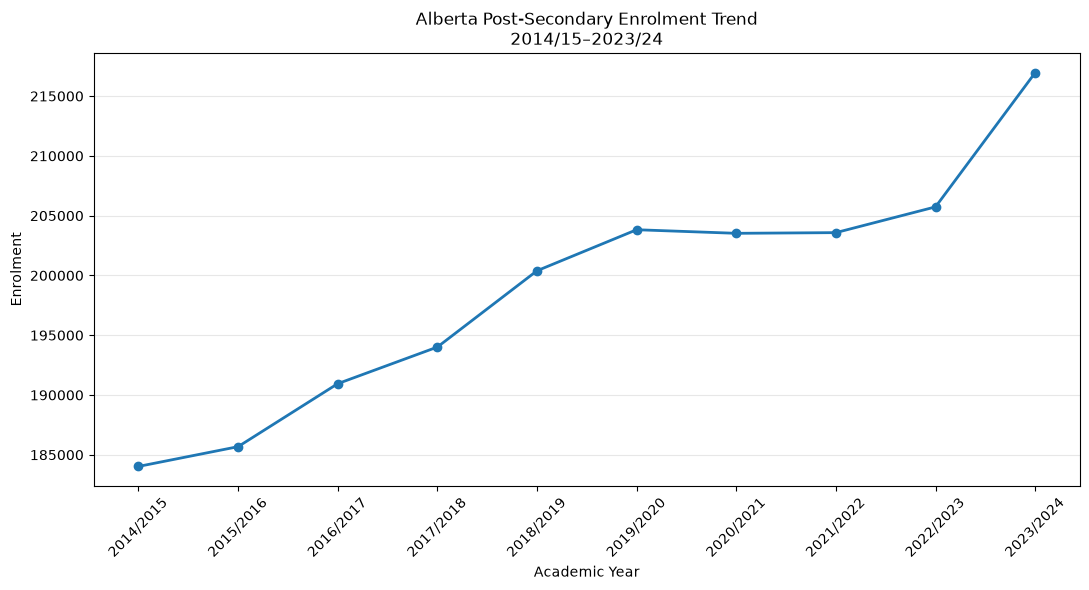

In [11]:
plt.figure(figsize=(11, 6))

plt.plot(
    alberta["Academic_Year"],
    alberta["Enrolment"],
    marker="o",
    linewidth=2
)

plt.title(
    "Alberta Post-Secondary Enrolment Trend\n2014/15–2023/24"
)

plt.xlabel("Academic Year")
plt.ylabel("Enrolment")

plt.xticks(rotation=45)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

In [12]:
ualberta = (
    df[
        (df["Institution"] == "University of Alberta")
        & (df["Record_Type"] == "Institution")
    ]
    .sort_values("Academic_Year_Start")
    .copy()
)

ualberta[
    ["Academic_Year", "Enrolment"]
]

,Academic_Year,Enrolment
230,2014/2015,38520
231,2015/2016,37716
232,2016/2017,38244
233,2017/2018,39363
234,2018/2019,40017
235,2019/2020,40590
236,2020/2021,42270
237,2021/2022,43905
238,2022/2023,44535
239,2023/2024,45306


In [13]:
uofa_start = ualberta.iloc[0]["Enrolment"]
uofa_end = ualberta.iloc[-1]["Enrolment"]

uofa_growth = (
    (uofa_end - uofa_start)
    / uofa_start
) * 100

uofa_cagr = (
    (uofa_end / uofa_start)
    ** (1 / number_of_periods)
    - 1
) * 100

print(f"Starting enrolment: {uofa_start:,.0f}")
print(f"Ending enrolment: {uofa_end:,.0f}")
print(f"Absolute change: {uofa_end - uofa_start:,.0f}")
print(f"Overall growth: {uofa_growth:.2f}%")
print(f"CAGR: {uofa_cagr:.2f}%")

Starting enrolment: 38,520
Ending enrolment: 45,306
Absolute change: 6,786
Overall growth: 17.62%
CAGR: 1.82%


In [14]:
comparison = alberta[
    ["Academic_Year", "Academic_Year_Start", "Enrolment"]
].merge(
    ualberta[
        ["Academic_Year", "Enrolment"]
    ],
    on="Academic_Year",
    suffixes=("_Alberta", "_UofA")
)

comparison

,Academic_Year,Academic_Year_Start,Enrolment_Alberta,Enrolment_UofA
0,2014/2015,2014,184026,38520
1,2015/2016,2015,185679,37716
2,2016/2017,2016,190947,38244
3,2017/2018,2017,194010,39363
4,2018/2019,2018,200391,40017
5,2019/2020,2019,203823,40590
6,2020/2021,2020,203523,42270
7,2021/2022,2021,203580,43905
8,2022/2023,2022,205734,44535
9,2023/2024,2023,216957,45306


In [15]:
comparison["UofA_Share_Pct"] = (
    comparison["Enrolment_UofA"]
    / comparison["Enrolment_Alberta"]
    * 100
)

In [16]:
comparison[
    [
        "Academic_Year",
        "Enrolment_Alberta",
        "Enrolment_UofA",
        "UofA_Share_Pct"
    ]
]

,Academic_Year,Enrolment_Alberta,Enrolment_UofA,UofA_Share_Pct
0,2014/2015,184026,38520,20.93
1,2015/2016,185679,37716,20.31
2,2016/2017,190947,38244,20.03
3,2017/2018,194010,39363,20.29
4,2018/2019,200391,40017,19.97
5,2019/2020,203823,40590,19.91
6,2020/2021,203523,42270,20.77
7,2021/2022,203580,43905,21.57
8,2022/2023,205734,44535,21.65
9,2023/2024,216957,45306,20.88


In [17]:
comparison["Alberta_Index"] = (
    comparison["Enrolment_Alberta"]
    / comparison["Enrolment_Alberta"].iloc[0]
    * 100
)

comparison["UofA_Index"] = (
    comparison["Enrolment_UofA"]
    / comparison["Enrolment_UofA"].iloc[0]
    * 100
)

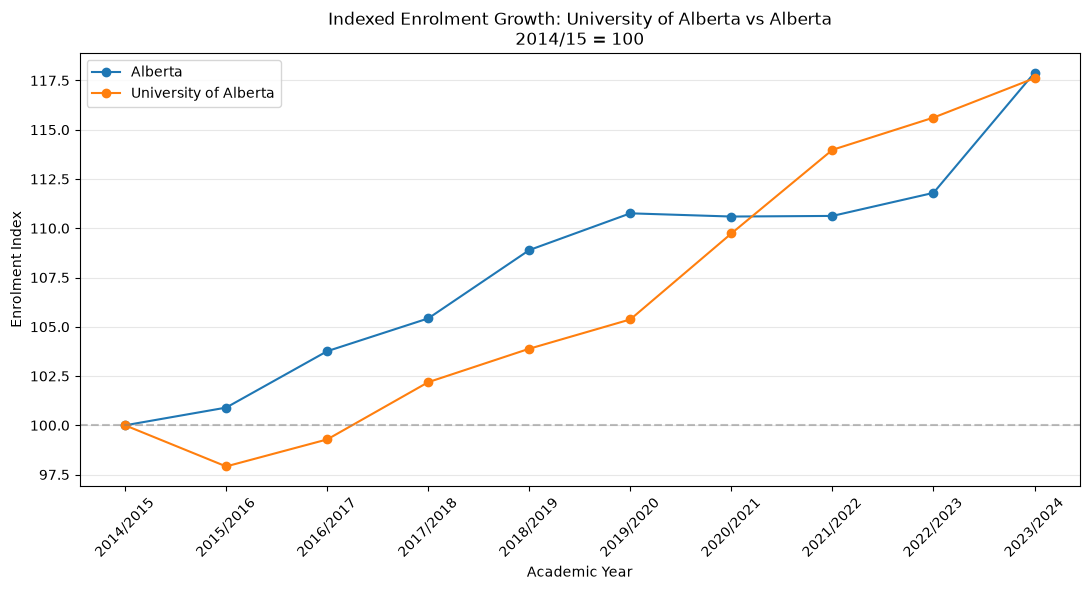

In [18]:
plt.figure(figsize=(11, 6))

plt.plot(
    comparison["Academic_Year"],
    comparison["Alberta_Index"],
    marker="o",
    label="Alberta"
)

plt.plot(
    comparison["Academic_Year"],
    comparison["UofA_Index"],
    marker="o",
    label="University of Alberta"
)

plt.axhline(
    100,
    color="gray",
    linestyle="--",
    alpha=0.5
)

plt.title(
    "Indexed Enrolment Growth: University of Alberta vs Alberta\n"
    "2014/15 = 100"
)

plt.xlabel("Academic Year")
plt.ylabel("Enrolment Index")

plt.xticks(rotation=45)
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## Preliminary Findings

- Total reported Alberta postsecondary enrolment increased from 184,026
  in 2014/15 to 216,957 in 2023/24, an increase of 32,931 students
  (17.89%).

- Alberta's compound annual enrolment growth rate over the period was
  approximately 1.85%.

- Growth was not uniform. Alberta recorded its weakest year-over-year
  change in 2020/21 (-0.15%), followed by almost no growth in 2021/22
  (+0.03%).

- The strongest year-over-year increase occurred in 2023/24 (+5.46%).

- University of Alberta enrolment increased from 38,520 to 45,306,
  representing growth of 17.62% and a CAGR of approximately 1.82%.

- Over the full study period, University of Alberta enrolment therefore
  grew at a rate very similar to the Alberta postsecondary system overall.

- University of Alberta's share of reported Alberta enrolment was not
  constant. It declined from 20.93% in 2014/15 to 19.91% in 2019/20,
  increased to 21.65% by 2022/23, and returned to 20.88% in 2023/24.

### Interpretation Note

These results identify historical patterns rather than their causes.
Changes in enrolment may be associated with demographic, economic,
institutional, policy, immigration, labour-market, or other factors.
Additional data is required before attributing these patterns to any
specific factor.

# Analysis 4 — Institutional Growth Comparison

This analysis compares enrolment growth across individual Alberta
postsecondary institutions between 2014/15 and 2023/24.

In [19]:
institutions = df[
    df["Record_Type"] == "Institution"
].copy()

In [20]:
start_year = institutions[
    institutions["Academic_Year"] == "2014/2015"
][
    ["Institution", "Enrolment"]
].rename(
    columns={"Enrolment": "Enrolment_2014_15"}
)

end_year = institutions[
    institutions["Academic_Year"] == "2023/2024"
][
    ["Institution", "Enrolment"]
].rename(
    columns={"Enrolment": "Enrolment_2023_24"}
)

In [21]:
institution_growth = start_year.merge(
    end_year,
    on="Institution",
    how="inner"
)

In [22]:
institution_growth["Absolute_Change"] = (
    institution_growth["Enrolment_2023_24"]
    - institution_growth["Enrolment_2014_15"]
)

In [23]:
institution_growth["Growth_Pct"] = (
    institution_growth["Absolute_Change"]
    / institution_growth["Enrolment_2014_15"]
    * 100
)

In [24]:
institution_growth = institution_growth.sort_values(
    "Growth_Pct",
    ascending=False
).reset_index(drop=True)

institution_growth

,Institution,Enrolment_2014_15,Enrolment_2023_24,Absolute_Change,Growth_Pct
0,NorQuest College,4212,10299,6087,144.52
1,Portage College,759,1569,810,106.72
2,Concordia University of Edmonton,1506,2568,1062,70.52
3,Olds College,1371,2223,852,62.14
4,Northern Lakes College,1389,1944,555,39.96
5,Bow Valley College,6891,8931,2040,29.60
6,Red Deer Polytechnic,3345,4242,897,26.82
7,St. Mary's University,732,924,192,26.23
8,Keyano College,1434,1809,375,26.15
9,Lakeland College,1959,2469,510,26.03


In [25]:
institution_growth.head(5)

,Institution,Enrolment_2014_15,Enrolment_2023_24,Absolute_Change,Growth_Pct
0,NorQuest College,4212,10299,6087,144.52
1,Portage College,759,1569,810,106.72
2,Concordia University of Edmonton,1506,2568,1062,70.52
3,Olds College,1371,2223,852,62.14
4,Northern Lakes College,1389,1944,555,39.96


In [26]:
institution_growth.tail(5)

,Institution,Enrolment_2014_15,Enrolment_2023_24,Absolute_Change,Growth_Pct
20,Grant MacEwan University,15870,16101,231,1.46
21,Medicine Hat College,2271,2268,-3,-0.13
22,Northwestern Polytechnic,1995,1908,-87,-4.36
23,Athabasca University,17577,16005,-1572,-8.94
24,Burman University,474,333,-141,-29.75


In [27]:
institution_growth.sort_values(
    "Absolute_Change",
    ascending=False
).head(10)

,Institution,Enrolment_2014_15,Enrolment_2023_24,Absolute_Change,Growth_Pct
10,University of Calgary,31308,38715,7407,23.66
13,University of Alberta,38520,45306,6786,17.62
0,NorQuest College,4212,10299,6087,144.52
12,Mount Royal University,12372,14709,2337,18.89
11,Northern Alberta Institute of Technology,10833,12993,2160,19.94
5,Bow Valley College,6891,8931,2040,29.60
2,Concordia University of Edmonton,1506,2568,1062,70.52
17,Southern Alberta Institute of Technology,14307,15306,999,6.98
6,Red Deer Polytechnic,3345,4242,897,26.82
3,Olds College,1371,2223,852,62.14


# Analysis 5 — Contribution to Alberta Enrolment Growth

Percentage growth identifies institutions that expanded rapidly relative
to their original size, but it does not show which institutions contributed
the largest number of additional enrolments.

This analysis measures each institution's contribution to the net change
in reported Alberta postsecondary enrolment between 2014/15 and 2023/24.

In [28]:
alberta_absolute_growth = (
    alberta_end - alberta_start
)

print(
    f"Alberta net enrolment increase: "
    f"{alberta_absolute_growth:,.0f}"
)

Alberta net enrolment increase: 32,931


In [29]:
institution_growth["Contribution_to_Alberta_Growth_Pct"] = (
    institution_growth["Absolute_Change"]
    / alberta_absolute_growth
    * 100
)

In [30]:
growth_contribution = (
    institution_growth
    .sort_values(
        "Absolute_Change",
        ascending=False
    )
    .reset_index(drop=True)
)

growth_contribution[
    [
        "Institution",
        "Absolute_Change",
        "Contribution_to_Alberta_Growth_Pct"
    ]
].head(10)

,Institution,Absolute_Change,Contribution_to_Alberta_Growth_Pct
0,University of Calgary,7407,22.49
1,University of Alberta,6786,20.61
2,NorQuest College,6087,18.48
3,Mount Royal University,2337,7.10
4,Northern Alberta Institute of Technology,2160,6.56
5,Bow Valley College,2040,6.19
6,Concordia University of Edmonton,1062,3.22
7,Southern Alberta Institute of Technology,999,3.03
8,Red Deer Polytechnic,897,2.72
9,Olds College,852,2.59


In [31]:
top3_change = (
    growth_contribution
    .head(3)["Absolute_Change"]
    .sum()
)

top3_contribution = (
    top3_change
    / alberta_absolute_growth
    * 100
)

print(f"Top 3 institutions added: {top3_change:,.0f}")
print(
    f"Share of Alberta net growth: "
    f"{top3_contribution:.2f}%"
)

Top 3 institutions added: 20,280
Share of Alberta net growth: 61.58%


In [35]:
#The three largest contributors to net enrolment growth—University of Calgary, University of Alberta and NorQuest College—collectively 
#added 20,280 enrolments, 
#equivalent to approximately 61.6% of Alberta's net increase over the period.

Analysis 6 — Growth vs institution size

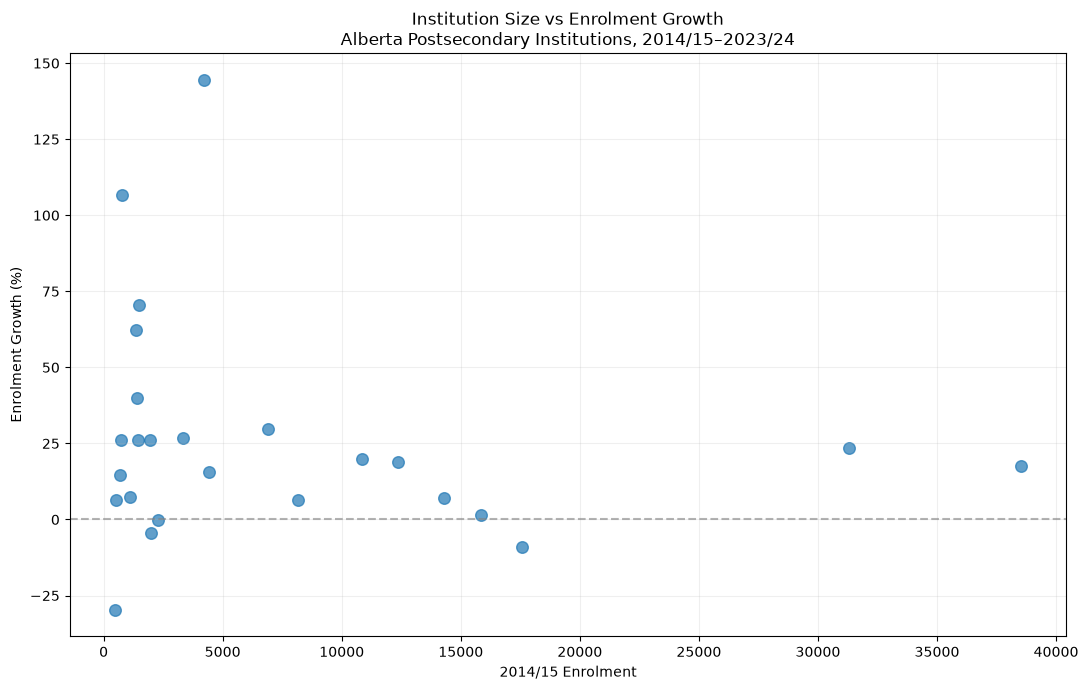

In [36]:
plt.figure(figsize=(11, 7))

plt.scatter(
    institution_growth["Enrolment_2014_15"],
    institution_growth["Growth_Pct"],
    s=70,
    alpha=0.7
)

plt.axhline(
    0,
    color="gray",
    linestyle="--",
    alpha=0.6
)

plt.title(
    "Institution Size vs Enrolment Growth\n"
    "Alberta Postsecondary Institutions, 2014/15–2023/24"
)

plt.xlabel("2014/15 Enrolment")
plt.ylabel("Enrolment Growth (%)")

plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

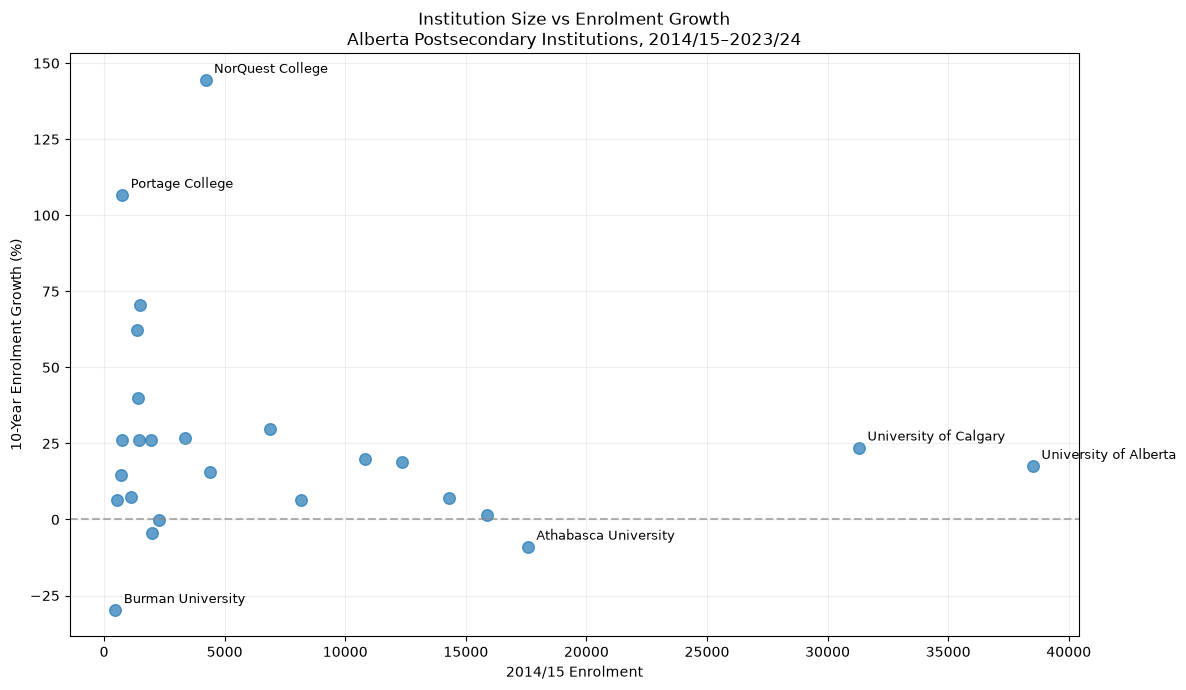

In [37]:
institutions_to_label = [
    "University of Alberta",
    "University of Calgary",
    "NorQuest College",
    "Athabasca University",
    "Burman University",
    "Portage College"
]

plt.figure(figsize=(12, 7))

plt.scatter(
    institution_growth["Enrolment_2014_15"],
    institution_growth["Growth_Pct"],
    s=70,
    alpha=0.7
)

for _, row in institution_growth.iterrows():
    if row["Institution"] in institutions_to_label:
        plt.annotate(
            row["Institution"],
            (
                row["Enrolment_2014_15"],
                row["Growth_Pct"]
            ),
            xytext=(6, 5),
            textcoords="offset points",
            fontsize=9
        )

plt.axhline(
    0,
    color="gray",
    linestyle="--",
    alpha=0.6
)

plt.title(
    "Institution Size vs Enrolment Growth\n"
    "Alberta Postsecondary Institutions, 2014/15–2023/24"
)

plt.xlabel("2014/15 Enrolment")
plt.ylabel("10-Year Enrolment Growth (%)")

plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

### Preliminary Interpretation

Institutional growth varied substantially across Alberta's postsecondary
system.

NorQuest College recorded the largest percentage increase among the
institutions analyzed, growing from 4,212 enrolments in 2014/15 to
10,299 in 2023/24 (+144.52%).

However, percentage growth alone can overemphasize changes at smaller
institutions. In absolute terms, the University of Calgary (+7,407),
University of Alberta (+6,786), and NorQuest College (+6,087) recorded
the largest increases.

At the other end of the distribution, several institutions experienced
little growth or declining enrolment over the study period, demonstrating
that Alberta's overall enrolment expansion was not evenly distributed
across institutions.

These differences warrant further investigation using institution type,
student status, field of study, and other dimensions before potential
causes are inferred.

### Key Finding

The three largest contributors to net enrolment growth — University of
Calgary, University of Alberta, and NorQuest College — collectively added
20,280 enrolments between 2014/15 and 2023/24.

This increase is equivalent to approximately 61.6% of Alberta's net
postsecondary enrolment increase over the same period.